# 03b — Run the embedding DiD for all 26 sites and compare with band-mean DiD

Executes the **source of `02_DiD_estimator_feature09.ipynb`** (= the collaborator's code with the four
declaration edits) once per treatment site, by setting the `EMBED_DID_SITE` env var and
`exec`-ing the notebook's own code cell in a fresh namespace — so the per-site
computation is literally the same code, 26 times. Display-only adjustment in this
runner: `plt.show` is a no-op and figures are closed between sites (the feature-based `comparison.png`
files are still written by the feature-based own code); stdout is buffered to one line per site.

Outputs: `embed_did_effects.csv` (aggregated per-dimension summaries),
per-site effect-vector norms, an algebraic verification of the equal-weight average,
and a rank comparison against the band-mean equal-weight DiD (the collaborator's
original feature representation, from `../site_band_features.csv`).

> **REORG EDIT (2026-08-15, logged):** this notebook and its three output CSVs moved to `same_repr/` (the *same-representation, feature-based-donors* ablation arm), separating it from the kNN-donor experiment in the parent folder. Code changes: added `OUT = ED / "same_repr"` and redirected the three `to_csv` targets from `ED` to `OUT`. `ED` still points at the parent folder, where the shared estimator `02_DiD_estimator_feature09.ipynb` lives. Nothing else changed; re-executed after the move.

> **RENAME (2026-08-15, logged):** notebooks renumbered to OUR workflow order; feature-based-derived notebooks carry a `_featureNN` suffix. Old→new: 09_embed_DiD→02_DiD_estimator_feature09, 06_embed_knn_matching→01_knn_donor_matching_her06, 12_run_knn_and_compare→03_DiD_all_pairs, 12b→04_effect_rank_table, 11→05_solver_verification_vs_R, 13→06_decode_quality_eval, same_repr/10→same_repr/03b_run_featureDonors_and_compare.
>
> **Updates since (2026-08-16):** further renames — `01_knn_donor_matching_her06`→`01_knn_donor_matching`, `05_solver_verification_vs_R`→`00_solver_verification_vs_R`, `04_effect_rank_table` merged into `03_DiD_all_pairs`; `06_decode_quality_eval` (later `04_decode_quality_eval`) was REPLACED by `04_tokenizer_space_pipeline`, the coherent tokenizer-space arm.

> **SWAP (2026-08-15, logged):** 01 and 02 exchanged numbers so numbering equals execution order (donor selection runs before the estimator): the estimator is now `02_DiD_estimator_feature09.ipynb`, donor matching is `01_knn_donor_matching_her06.ipynb`. The load path in this notebook was updated accordingly. Re-executed after the edit.

In [1]:
import io
import json
import os
from contextlib import redirect_stdout
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("/data/wang/junh/githubs/latent-synthetic-control")
ED = ROOT / "REAP" / "notebooks" / "embed_DiD"
OUT = ED / "same_repr"  # REORG EDIT 2026-08-15
NBK = ROOT / "REAP" / "notebooks"
EMB = ROOT / "REAP" / "data" / "embeddings"
TEST = EMB / "test"

C_CONTROL, C_TREAT, C_ACCENT = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.titlesize": 10,
    "axes.labelsize": 9, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "legend.fontsize": 8, "figure.titlesize": 12,
})

mt = pd.read_csv(EMB / "finals" / "site_matching_table.csv")
treatments = sorted(mt["treatment_site_id"].astype(str).unique())
print(len(treatments), "treatment sites")

nb09 = json.load(open(ED / "02_DiD_estimator_feature09.ipynb"))
src09 = "".join(next(c for c in nb09["cells"] if c["cell_type"] == "code")["source"])
print("01_equal_weight_DiD_feature09 source:", len(src09), "chars")

26 treatment sites
01_equal_weight_DiD_feature09 source: 47559 chars


## Execute the feature-based code once per treatment site

In [2]:
_show = plt.show
plt.show = lambda *a, **k: None  # display-only: suppress inline rendering, 26 x 3 figs
ran, failed = [], []
for sid in treatments:
    os.environ["EMBED_DID_SITE"] = sid
    buf = io.StringIO()
    try:
        g = {"__name__": "__main__"}
        with redirect_stdout(buf):
            exec(src09, g)
        ran.append(sid)
        print(f"{sid}: ok")
    except Exception as e:  # keep going; report at the end
        failed.append((sid, repr(e)))
        print(f"{sid}: FAILED {e!r}")
    finally:
        plt.close("all")
plt.show = _show
os.environ.pop("EMBED_DID_SITE", None)
print(f"\ncompleted {len(ran)}/{len(treatments)}; failures: {failed}")
assert not failed

treatment_0001: ok


treatment_0002: ok


treatment_0003: ok


treatment_0004: ok


treatment_0005: ok


...

treatment_0022: ok


treatment_0023: ok


treatment_0024: ok


treatment_0025: ok


treatment_0027: ok

completed 26/26; failures: []


## Aggregate the 26 per-site summaries

In [3]:
parts = []
for sid in treatments:
    f = TEST / sid / "counterfactual_feature_summary.csv"
    df = pd.read_csv(f)
    assert len(df) == 768 * 2, (sid, len(df))
    parts.append(df)
effects = pd.concat(parts, ignore_index=True)
effects.to_csv(OUT / "embed_did_effects.csv", index=False)
print("aggregated:", effects.shape, "->", OUT / "embed_did_effects.csv")
print(effects.groupby("sensor").size().rename("rows").to_string())

aggregated: (39936, 21) -> /data/wang/junh/githubs/latent-synthetic-control/REAP/notebooks/embed_DiD/same_repr/embed_did_effects.csv
sensor
sentinel1    19968
sentinel2    19968


## Algebraic verification of the equal-weight average

On 1×1 rasters, the feature-based pixel-wise `np.nanmean` across the 10 control images IS the plain
mean of the 10 embedding vectors. Verify the feature-based `mean_control_before_mean` output against
the mean computed directly from `site_embeddings.csv`.

In [4]:
emb = pd.read_csv(EMB / "site_embeddings.csv")
ecols = [c for c in emb.columns if c.startswith("emb_")]
emb_idx = emb.set_index(["site_id", "sensor", "period"])[ecols]

worst = 0.0
for sid in treatments:
    donors = mt.loc[mt["treatment_site_id"] == sid, "counterfactual_site_id"].astype(str)
    for sensor in ("sentinel1", "sentinel2"):
        direct = emb_idx.loc[[(d, sensor, "before") for d in donors]].mean(axis=0).to_numpy()
        feature_based = (effects.query("treatment_site_id == @sid and sensor == @sensor")
                .set_index("band")["mean_control_before_mean"]
                .loc[ecols].to_numpy())
        worst = max(worst, float(np.abs(direct - feature_based).max()))
print("max |the feature-based mean_control - direct mean of 10 embeddings| over all sites/sensors:", worst)
assert worst < 1e-5

max |the feature-based mean_control - direct mean of 10 embeddings| over all sites/sensors: 1.0490417494679605e-06


## Effect summary per site

For each site × sensor: the L2 norm of the 768-dim `mean_adjusted_effect` vector
(equal-weight DiD in embedding space), alongside the norm of the raw treated change and
the **pre-period imbalance** ‖e(treated,before) − mean e(donors,before)‖ — the
embedding-space analog of covariate imbalance, and the quantity estimated weights would
shrink in the SC follow-up.

In [5]:
rows = []
for sid in treatments:
    donors = mt.loc[mt["treatment_site_id"] == sid, "counterfactual_site_id"].astype(str)
    for sensor in ("sentinel1", "sentinel2"):
        sub = (effects.query("treatment_site_id == @sid and sensor == @sensor")
               .set_index("band").loc[ecols])
        eff = sub["mean_adjusted_effect"].to_numpy()
        chg = sub["treatment_change_mean"].to_numpy()
        pre_gap = (emb_idx.loc[(sid, sensor, "before")].to_numpy()
                   - emb_idx.loc[[(d, sensor, "before") for d in donors]].mean(axis=0).to_numpy())
        rows.append({"site": sid, "sensor": sensor,
                     "effect_norm": float(np.linalg.norm(eff)),
                     "treated_change_norm": float(np.linalg.norm(chg)),
                     "pre_imbalance_norm": float(np.linalg.norm(pre_gap))})
site_norms = pd.DataFrame(rows)
site_norms.to_csv(OUT / "embed_did_site_norms.csv", index=False)
print(site_norms.groupby("sensor")[["effect_norm", "treated_change_norm",
                                    "pre_imbalance_norm"]].describe().round(3).T.to_string())

sensor                     sentinel1  sentinel2
effect_norm         count     26.000     26.000
                    mean       4.468      2.582
                    std        0.725      0.618
                    min        3.103      1.805
                    25%        3.961      2.149
                    50%        4.311      2.448
                    75%        4.837      2.981
                    max        6.222      4.312
treated_change_norm count     26.000     26.000
                    mean       6.795      5.567
                    std        1.224      1.355
                    min        3.840      3.307
                    25%        6.126      4.674
                    50%        6.820      5.479
                    75%        7.572      6.563
                    max        9.163      8.081
pre_imbalance_norm  count     26.000     26.000
                    mean       5.115      2.913
                    std        0.962      0.592
                    min        3.779    

## Comparison with the band-mean DiD (the feature-based original representation)

Same estimator (equal weights, same donors), input representation the only difference.
Band-space DiD per site from `../site_band_features.csv` ("change" rows = pixelwise
change means, the feature-based convention). Effect norms are not on a common scale across
representations, so the comparison is **rank-based across the 26 sites**: does the
embedding arm order sites the way the physical bands do?

Spearman rank correlations across the 26 sites (|band DiD| vs embedding effect norm):
  emb_effect_sentinel2     vs |bandDiD_NDVI        |  rho=-0.006  p=0.975
  emb_effect_sentinel2     vs |bandDiD_B11         |  rho=-0.080  p=0.696
  emb_effect_sentinel1     vs |bandDiD_VV_minus_VH |  rho=-0.162  p=0.428
  emb_effect_sentinel1     vs |bandDiD_VH          |  rho=-0.065  p=0.754


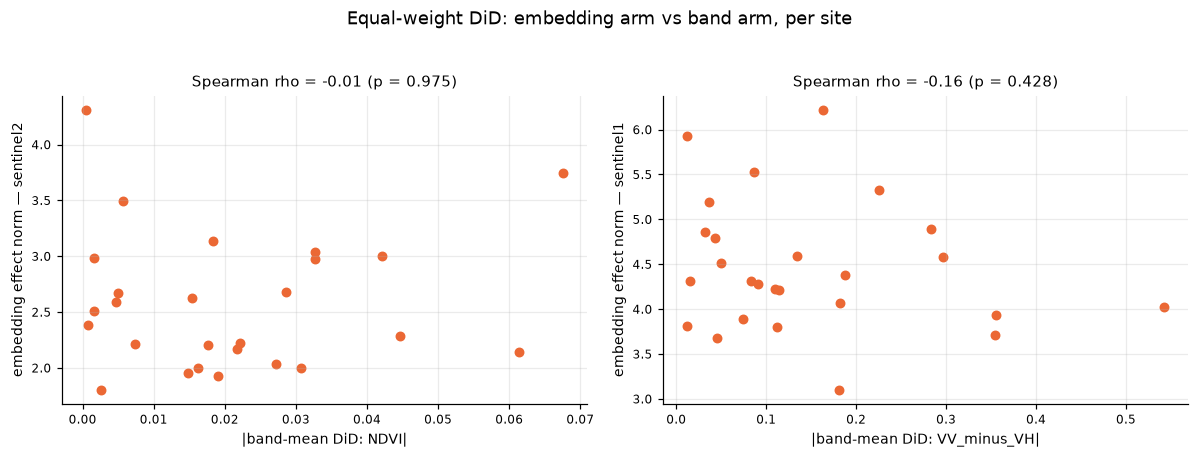

In [6]:
from scipy.stats import spearmanr

feats = pd.read_csv(NBK / "site_band_features.csv")
chg = (feats.query("period == 'change'")
       .set_index(["site_id", "sensor"]))

def band_did(sid, sensor, band):
    donors = mt.loc[mt["treatment_site_id"] == sid, "counterfactual_site_id"].astype(str)
    t = chg.loc[(sid, sensor), band]
    c = np.mean([chg.loc[(d, sensor), band] for d in donors])
    return t - c

comp = site_norms.pivot(index="site", columns="sensor", values="effect_norm")
comp.columns = [f"emb_effect_{c}" for c in comp.columns]
for band, sensor in [("NDVI", "sentinel2"), ("B11", "sentinel2"),
                     ("VV_minus_VH", "sentinel1"), ("VH", "sentinel1")]:
    comp[f"bandDiD_{band}"] = [band_did(s, sensor, band) for s in comp.index]
comp.round(4).to_csv(OUT / "embed_vs_band_did.csv")

pairs = [("emb_effect_sentinel2", "bandDiD_NDVI"),
         ("emb_effect_sentinel2", "bandDiD_B11"),
         ("emb_effect_sentinel1", "bandDiD_VV_minus_VH"),
         ("emb_effect_sentinel1", "bandDiD_VH")]
print("Spearman rank correlations across the 26 sites (|band DiD| vs embedding effect norm):")
for a, b in pairs:
    rho, p = spearmanr(comp[a], comp[b].abs())
    print(f"  {a:24s} vs |{b:20s}|  rho={rho:+.3f}  p={p:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (a, b) in zip(axes, [pairs[0], pairs[2]]):
    ax.scatter(comp[b].abs(), comp[a], color=C_TREAT, s=30)
    rho, p = spearmanr(comp[a], comp[b].abs())
    ax.set_xlabel(f"|band-mean DiD: {b.replace('bandDiD_', '')}|")
    ax.set_ylabel(a.replace("emb_effect_", "embedding effect norm — "))
    ax.set_title(f"Spearman rho = {rho:+.2f} (p = {p:.3f})")
fig.suptitle("Equal-weight DiD: embedding arm vs band arm, per site", y=1.03)
plt.tight_layout(); plt.show()

## Reading

- The estimator here is **the feature-based code verbatim** (declaration edits only): pixel-wise mean
  over 10 controls → change → adjusted effect, run on 768-d embeddings where each
  "band" is one embedding coordinate and every image is one pixel.
- `effect_norm` summarizes the 768-dim equal-weight DiD per site; within a sensor it is
  comparable across sites, but NOT across sensors/encoders (different spaces) — hence
  rank-based comparison only. Calibrated inference (placebo ranks, as in
  `../02_did_vs_synthetic_control.ipynb` §4) is the next step.
- `pre_imbalance_norm` is the embedding-space match quality under equal weights: the
  quantity an estimated-weight SC (simplex QP on before-embeddings) would minimize.
  That comparison — equal vs estimated weights in embedding space, and the
  planted-mixture composability gate — is the follow-up experiment
  (see `../../Docs/encoder_selection_2026-08-14.md` §4).
